In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical



In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


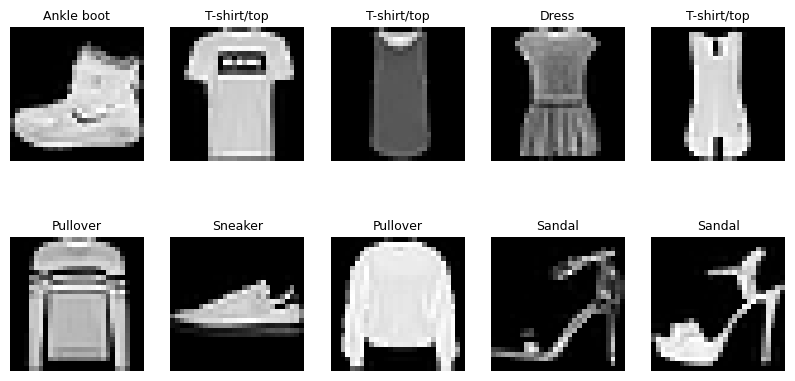

In [ ]:
# Define the text labels for Fashion-MNIST
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Plotting the first 10 fashion items with their actual names
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")
plt.show()

In [ ]:
# --- Preprocessing ---
X_train = X_train / 255.0
X_test = X_test / 255.0

x_train = X_train.reshape(-1, 28, 28, 1)
x_test = X_test.reshape(-1, 28, 28, 1)

Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# --- Build CNN Model ---
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# --- Train ---
history = model.fit(
    x_train, Y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# --- Evaluate ---
test_loss, test_accuracy = model.evaluate(x_test, Y_test)
print(f"\nTest Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 22ms/step - accuracy: 0.0989 - loss: 2.3029 - val_accuracy: 0.0957 - val_loss: 2.3029
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.0980 - loss: 2.3028 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.0996 - loss: 2.3027 - val_accuracy: 0.0983 - val_loss: 2.3028
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.0987 - loss: 2.3028 - val_accuracy: 0.1003 - val_loss: 2.3027
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.0991 - loss: 2.3028 - val_accuracy: 0.0983 - val_loss: 2.3028
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.0973 - loss: 2.3028 - val_accuracy: 0.1003 - val_loss: 2.3026
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.0980 - loss: 2.3028 - val_accuracy: 0.0983 - val_loss: 2.3028
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.0976 -

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,386 (442.91 KB)

 Trainable params: 113,386 (442.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model=Sequential()
#first convolution layer
model.add(Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)))
#first pooling layer
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10,activation="softmax"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


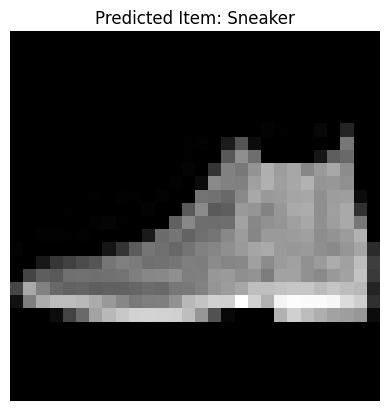

In [ ]:
sample = X_test[0]
prediction = model.predict(sample.reshape(1, 28, 28, 1))
predicted_class_idx = np.argmax(prediction)

plt.imshow(sample.reshape(28, 28), cmap='gray')
# Displaying the text label instead of the digit integer
plt.title(f"Predicted Item: {class_names[predicted_class_idx]}")
plt.axis('off')
plt.show()

Saving download1.jpg to download1 (5).jpg


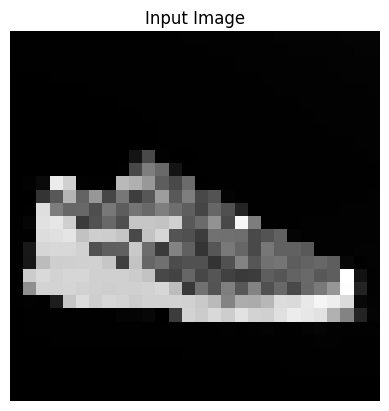

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Item: Sandal
Confidence Score: 11.686762 %


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. This triggers the file upload button in Colab
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# 2. Read and preprocess the image
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Resize the image to 28x28 to match Fashion-MNIST dimensions
img = cv2.resize(img, (28, 28))

# Invert colors (Fashion-MNIST expects a black background with white foreground)
img = 255 - img

# Normalize pixel values
img = img / 255.0

# Display the processed image
plt.imshow(img, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()

# Reshape for the CNN model structure (1 sample, 28x28 size, 1 color channel)
img = img.reshape(1, 28, 28, 1)

# 3. Predict the item using your trained model
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)

# Define the fashion item classes
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Print out the results
print(f"Predicted Item: {class_names[predicted_class_idx]}")
print("Confidence Score:", np.max(prediction) * 100, "%")